In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\tovar_moving.csv', index_col=['date'], parse_dates=['date'])
df

,qty
date,
2009-12-25,72314.0
2009-12-26,66586.0
2009-12-27,125199.0
2009-12-28,91544.0
2009-12-29,76995.0
...,...
2013-11-28,320717.0
2013-11-29,444416.0
2013-11-30,323577.0


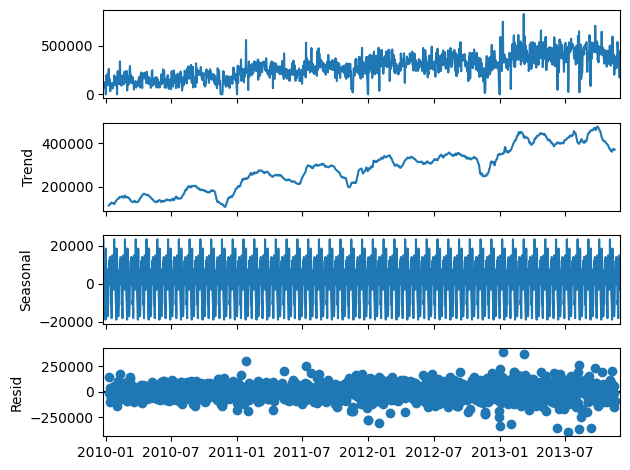

In [62]:
season = seasonal_decompose(df, model='additive', period=30)
season.plot()
plt.show()

In [63]:
test_df = df.iloc[-1]
train_df = df.iloc[:-1]
test_df

qty    423846.0
Name: 2013-12-02 00:00:00, dtype: float64

In [64]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['qty'].diff().dropna())
result


(-13.821839865226567,
 7.878856681052743e-26,
 19,
 1418,
 {'1%': -3.4349700122033804,
  '5%': -2.8635804131233096,
  '10%': -2.567856305330816},
 35899.722193720656)

In [65]:
df_new = df['qty'].diff().dropna()

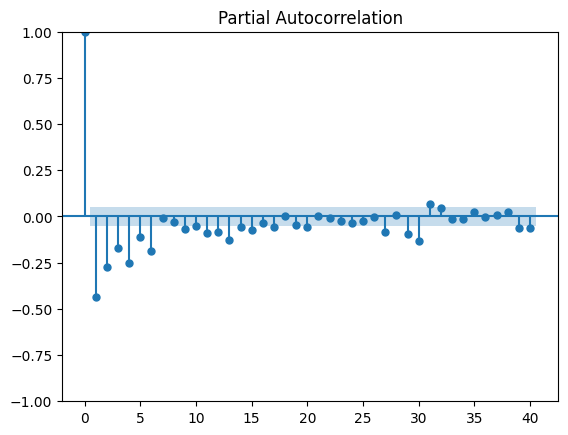

In [66]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_new, lags=40)
plt.show()

In [67]:
from statsmodels.tsa.ar_model import AutoReg
ar_model = AutoReg(train_df, lags=6).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                    qty   No. Observations:                 1438
Model:                     AutoReg(6)   Log Likelihood              -18221.056
Method:               Conditional MLE   S.D. of innovations          81248.064
Date:                Thu, 05 Feb 2026   AIC                          36458.111
Time:                        12:47:19   BIC                          36500.246
Sample:                    12-31-2009   HQIC                         36473.844
                         - 12-01-2013                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.047e+04   6160.175      4.946      0.000    1.84e+04    4.25e+04
qty.L1         0.3074      0.026     11.654      0.000       0.256       0.359
qty.L2         0.1582      0.027      5.835      0.0

c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [68]:
ar_pred = ar_model.predict(start=len(train_df), end=(len(train_df)), dynamic=False)
ar_pred

c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


2013-12-02    318174.284553
Freq: D, dtype: float64

In [69]:
from statsmodels.tsa.api import SimpleExpSmoothing
ses = SimpleExpSmoothing(train_df)
alpha = 0.7
model = ses.fit(smoothing_level = alpha, optimized = False)
exp_pred = model.forecast(1)
exp_pred

c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2013-12-02    225015.522647
Freq: D, dtype: float64

In [71]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing
ses = SimpleExpSmoothing(train_df)
alpha=0.7
model = ses.fit(smoothing_level = alpha, optimized=False)
exp_pred = model.forecast(1)
print(mean_squared_error(test_df, ar_pred))
print(mean_squared_error(test_df, exp_pred))


11166511445.472961
39533558724.37031


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
